In [143]:
import cv2 as cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pandas

kode diatas mengimpor beberapa library yang dibutuhkan. cv2 digunakan untuk membaca dan mengolah gambar, numpy dipakai karena gambar tersebut sebenarnya berupa array atau matriks angka, dan matplotlib digunakan untuk menampilkan gambar ke layar.

Kode dibawah ini digunakan untuk membaca dan menampilkan gambar bernama Meledak.PNG yang berada di dalam folder Assets. Pada baris meledak = plt.imread('Assets/Meledak.PNG'), program mengambil file gambar lalu menyimpannya ke dalam variabel meledak. Setelah gambar berhasil dibaca, data citra akan tersimpan dalam bentuk array yang berisi nilai intensitas warna RGB pada setiap piksel gambar. Selanjutnya, fungsi plt.imshow(meledak) digunakan untuk menampilkan citra yang telah disimpan pada variabel meledak ke dalam output visual. Kemudian, plt.show() berfungsi untuk memunculkan hasil tampilan gambar sehingga citra dapat terlihat pada notebook atau layar program. Secara keseluruhan, kode tersebut berfungsi untuk memuat dan menampilkan gambar digital menggunakan library Matplotlib pada Python.

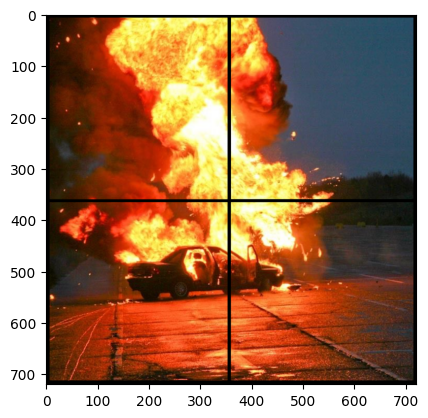

In [144]:
meledak = plt.imread('Assets/Meledak.PNG')
plt.imshow(meledak)
plt.show()

In [145]:
def fungsi_empat_s(gambar, a, b, c, d, mode='H'): 
    return gambar[a:b, c:d] if mode == 'H' else gambar[c:d, a:b]

Kode di atas digunakan untuk membagi citra meledak menjadi empat bagian berbeda menggunakan fungsi fungsi_empat_s(). Pada fungsi tersebut, parameter gambar digunakan sebagai input citra, sedangkan a, b, c, dan d digunakan untuk menentukan batas koordinat pemotongan gambar. Jika mode bernilai 'H', maka proses slicing dilakukan secara horizontal menggunakan format gambar[a:b, c:d], sedangkan mode selain 'H' akan menggunakan format gambar[c:d, a:b].

Setelah fungsi dibuat, program membagi gambar menjadi empat bagian yang disimpan ke dalam variabel part1, part2, part3, dan part4. Masing-masing bagian diambil berdasarkan koordinat tertentu sehingga menghasilkan potongan gambar yang berbeda. Variabel part1 berisi bagian kiri atas gambar, part2 berisi bagian kanan atas, part3 berisi bagian kiri bawah, dan part4 berisi bagian kanan bawah.

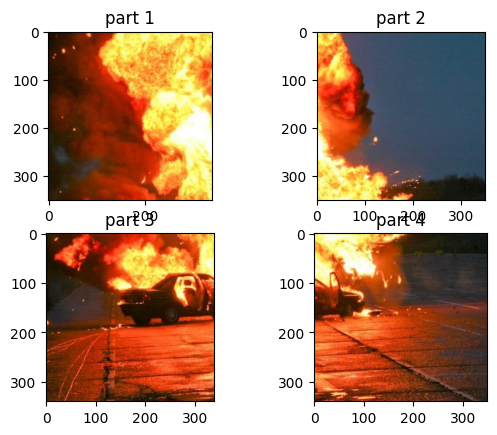

In [146]:
part1 = fungsi_empat_s(meledak, 10, 360, 10, 350, mode='H')
plt.subplot (2, 2, 1)
plt.imshow(part1, cmap='gray')
plt.title("part 1")

part2 = fungsi_empat_s(meledak, 10, 360, 360, 710, mode='H')
plt.subplot (2, 2, 2)
plt.imshow(part2, cmap='gray')
plt.title("part 2")

part3 = fungsi_empat_s(meledak, 370, 710, 10, 350, mode='H')
plt.subplot (2, 2, 3)
plt.imshow(part3, cmap='gray')
plt.title("part 3")

part4 = fungsi_empat_s(meledak, 370, 710, 360, 710, mode='H')
plt.subplot (2, 2, 4)
plt.imshow(part4, cmap='gray')
plt.title("part 4")

plt.show()

In [147]:
def merge_image(citra1, citra2, orientation='H'): 

    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), 
dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, 
citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], 
citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), 
dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, 
citra1.shape[2]), dtype=citra1.dtype) 
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 
0:citra2.shape[1]] = citra2 
    return gabungan 

Kode di atas digunakan untuk membuat fungsi merge_image() yang berfungsi menggabungkan dua citra menjadi satu gambar. Fungsi ini memiliki parameter citra1 dan citra2 sebagai gambar yang akan digabung, serta parameter orientation untuk menentukan arah penggabungan. Jika nilai orientation adalah 'H', maka gambar akan digabung secara horizontal atau menyamping. Program akan menghitung tinggi maksimum dari kedua gambar dan menjumlahkan lebarnya untuk membuat ukuran citra baru. Setelah itu dibuat array kosong menggunakan np.zeros() sebagai wadah hasil gabungan, lalu citra pertama ditempatkan di sisi kiri dan citra kedua ditempatkan di sisi kanan. Sebaliknya, jika orientation tidak bernilai 'H', maka gambar digabung secara vertikal dengan cara menambahkan tinggi kedua citra dan mengambil lebar maksimum. Dalam proses ini, citra pertama ditempatkan di bagian atas dan citra kedua ditempatkan di bagian bawah. Pada akhir fungsi, hasil penggabungan dikembalikan menggunakan return gabungan.

Kode pada bagian bawah digunakan untuk menjalankan fungsi penggabungan gambar yang telah dibuat sebelumnya. Variabel hasil_b digunakan untuk menyimpan hasil penggabungan part1 dan part3 secara vertikal, sedangkan hasil_c digunakan untuk menyimpan hasil penggabungan part2 dan part4 secara vertikal. Kedua hasil tersebut kemudian ditampilkan menggunakan plt.subplot() sehingga dapat dilihat berdampingan dalam satu tampilan. Setelah itu, program menggabungkan kembali hasil_b dan hasil_c secara horizontal menggunakan fungsi merge_image(). Hasil akhir penggabungan tersebut disimpan pada variabel hasil_akhir. Dengan proses ini, empat potongan gambar yang sebelumnya dipisahkan dapat disusun kembali menjadi citra utuh seperti gambar awal.

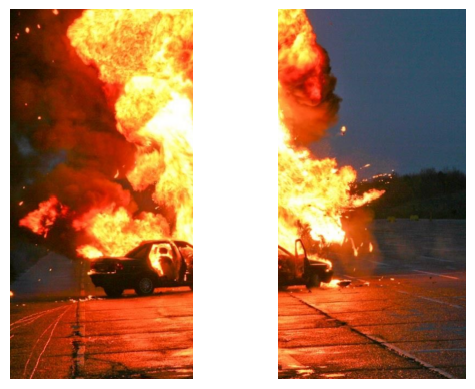

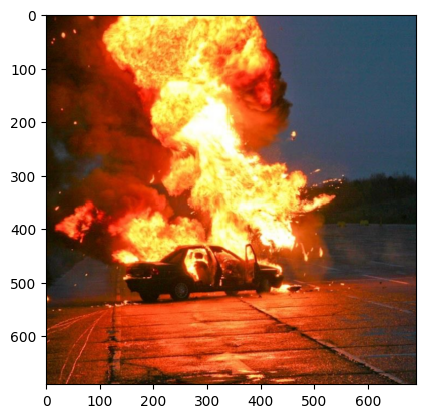

In [148]:
hasil_b = merge_image(part1, part3, orientation='v')
hasil_c = merge_image(part2, part4, orientation='v')
plt.subplot(1, 2, 1)
plt.imshow(hasil_b)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_c)
plt.axis('off')

plt.show()

hasil_akhir = merge_image(hasil_b, hasil_c, orientation='H')
plt.imshow(hasil_akhir)
plt.show()

Kode di bawah ini digunakan untuk mengubah citra berwarna menjadi citra grayscale atau keabuan. Pada baris greyscale = cv2.cvtColor(hasil_akhir, cv2.COLOR_BGR2GRAY), fungsi cv2.cvtColor() dari library OpenCV digunakan untuk melakukan konversi warna dari format BGR menjadi grayscale. Hasil konversi tersebut kemudian disimpan ke dalam variabel greyscale. Dalam citra grayscale, setiap piksel hanya memiliki satu nilai intensitas warna, yaitu dari hitam hingga putih, sehingga gambar tidak lagi memiliki warna asli RGB.

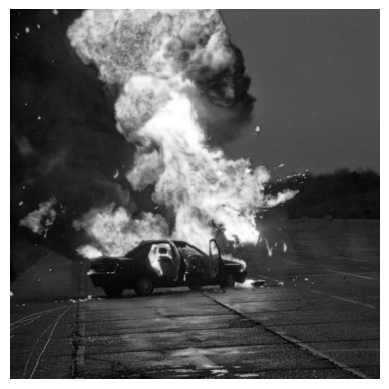

In [149]:
greyscale = cv2.cvtColor(hasil_akhir, cv2.COLOR_BGR2GRAY)
plt.imshow(greyscale, cmap='gray')
plt.axis('off')
plt.show()

In [150]:
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    hasil = np.zeros_like(citra, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

Kode di atas digunakan untuk membuat fungsi ekualisasi_histogram(citra) yang berfungsi meningkatkan kualitas kontras citra grayscale menggunakan metode histogram equalization. Pada awal fungsi, ukuran citra diambil menggunakan panjang, lebar = citra.shape. Selanjutnya, program membuat array histogram berukuran 256 menggunakan np.zeros() untuk menyimpan jumlah kemunculan setiap intensitas piksel dari 0 hingga 255. Dengan menggunakan perulangan for, program membaca setiap piksel pada citra lalu menambahkan jumlah kemunculan nilai intensitas tersebut ke dalam histogram.
Setelah histogram diperoleh, program membuat nilai cumulative distribution function (CDF) menggunakan array cdf. Nilai CDF dihitung dari penjumlahan kumulatif histogram sehingga menunjukkan distribusi kumulatif intensitas piksel. Kemudian program mencari nilai minimum CDF yang tidak bernilai nol dan melakukan normalisasi menggunakan rumus histogram equalization agar rentang intensitas menyebar lebih merata dari 0 sampai 255. Setelah proses normalisasi selesai, program membuat citra baru bernama hasil dan mengganti setiap nilai piksel citra asli dengan nilai hasil normalisasi histogram. Pada akhir fungsi, citra hasil ekualisasi dikembalikan menggunakan return hasil.

Kode pada bagian bawah digunakan untuk menjalankan fungsi ekualisasi histogram pada citra grayscale. Baris citra_gabung = (greyscale * 255).astype(np.uint8) digunakan untuk mengubah nilai citra grayscale menjadi format 8-bit agar sesuai dengan rentang intensitas 0–255. Setelah itu, ukuran citra disimpan ke dalam variabel panjang dan lebar, lalu fungsi ekualisasi_histogram() dipanggil dan hasilnya disimpan pada variabel hasil_ekualisasi.
Selanjutnya, program menampilkan citra sebelum dan sesudah proses ekualisasi menggunakan plt.subplot(). Bagian kiri menampilkan citra asli grayscale dengan judul “Citra sebelum ekualisasi”, sedangkan bagian kanan menampilkan citra hasil ekualisasi dengan judul “Citra setelah ekualisasi”. Fungsi plt.tight_layout() digunakan untuk mengatur jarak antar tampilan agar lebih rapi.

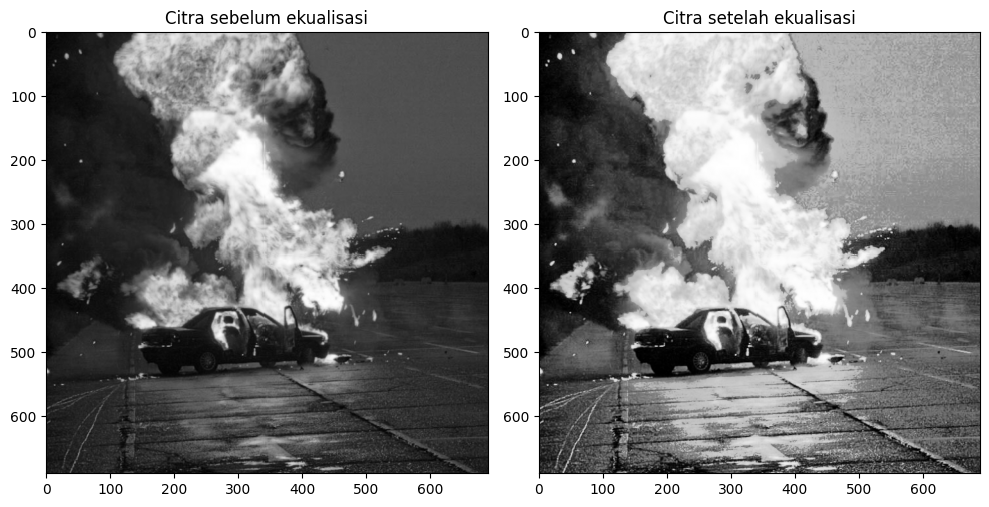

In [151]:
citra_gabung = (greyscale * 255).astype(np.uint8)

panjang, lebar = citra_gabung.shape
hasil_ekualisasi = ekualisasi_histogram(citra_gabung)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(citra_gabung, cmap='gray')
plt.title("Citra sebelum ekualisasi")
plt.subplot(1, 2, 2)
plt.imshow(hasil_ekualisasi, cmap='gray')
plt.title("Citra setelah ekualisasi")
plt.tight_layout()
plt.show()

In [152]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 
def plot_histogram(histogram, title, ImgColor): 
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

Kode di atas digunakan untuk membuat fungsi pembuatan dan penampilan histogram citra. Fungsi buat_hist(citra) digunakan untuk menghitung jumlah kemunculan setiap intensitas piksel pada citra grayscale. Pada awal fungsi, dibuat list histogram = [0] * 256 yang berisi 256 elemen nol untuk mewakili intensitas piksel dari 0 sampai 255. Selanjutnya, program mengambil ukuran tinggi dan lebar citra menggunakan len(). Dengan menggunakan perulangan for, setiap piksel pada citra dibaca satu per satu, lalu nilainya disimpan ke variabel val. Setelah itu, jumlah kemunculan intensitas tersebut ditambahkan ke dalam array histogram menggunakan histogram[val] += 1. Setelah seluruh piksel selesai dihitung, histogram dikembalikan menggunakan return histogram. 
Fungsi berikutnya yaitu plot_histogram(histogram, title, ImgColor) digunakan untuk menampilkan histogram dalam bentuk grafik batang. Fungsi plt.figure(figsize=(10,5)) digunakan untuk menentukan ukuran tampilan grafik. Selanjutnya, plt.xlabel() dan plt.ylabel() digunakan untuk memberikan label sumbu x dan y, sedangkan plt.title() digunakan untuk memberikan judul histogram. Fungsi plt.bar() digunakan untuk membuat grafik batang berdasarkan data histogram dengan warna yang ditentukan oleh parameter ImgColor. Terakhir, plt.show() digunakan untuk menampilkan grafik histogram ke layar.

Kode di bawah ini digunakan untuk menghitung dan menampilkan histogram citra sebelum dan sesudah proses ekualisasi histogram. Variabel histogram_ekualisasi digunakan untuk menyimpan histogram dari citra hasil ekualisasi, sedangkan histogram_greyscale digunakan untuk menyimpan histogram dari citra grayscale sebelum ekualisasi. Setelah histogram diperoleh, program membuat tampilan grafik menggunakan plt.figure(figsize=(10,5)).
Kemudian, fungsi plt.bar() pertama digunakan untuk menampilkan histogram citra sebelum ekualisasi dengan warna hijau (green) dan transparansi alpha=0.5. Histogram ini diberi label “Histogram Sebelum Ekualisasi”. Selanjutnya, plt.bar() kedua digunakan untuk menampilkan histogram citra setelah ekualisasi dengan warna merah (red) dan label “Histogram Setelah Ekualisasi”. Dengan menampilkan kedua histogram pada satu grafik, program dapat menunjukkan perbedaan distribusi intensitas piksel sebelum dan sesudah proses ekualisasi histogram dilakukan.

<BarContainer object of 256 artists>

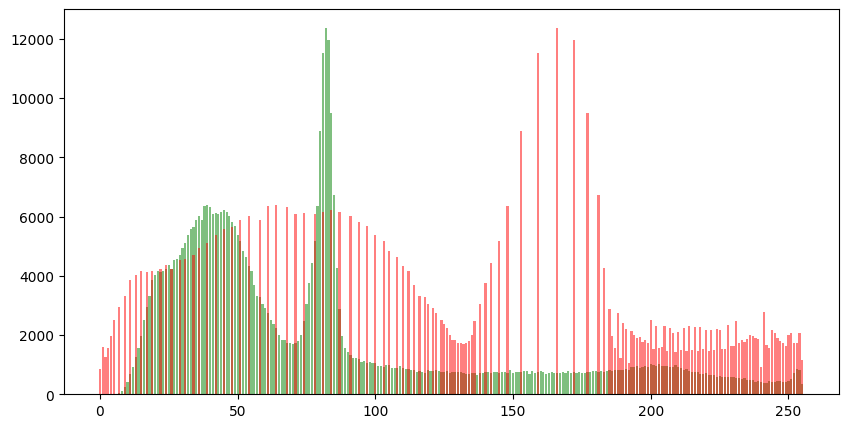

In [153]:

histogram_ekualisasi = buat_hist(hasil_ekualisasi)
histogram_greyscale = buat_hist(citra_gabung)
plt.figure(figsize=(10,5))
plt.bar(
    range(256),
    histogram_greyscale,
    color='green',
    alpha=0.5,
    label='Histogram Sebelum Ekualisasi'
)
plt.bar(
    range(256),
    histogram_ekualisasi,
    color='red',
    alpha=0.5,
    label='Histogram Setelah Ekualisasi'
)

Kode pada bagian ini digunakan untuk membaca dan menampilkan dua citra grayscale, yaitu citra Windut dan citra Bunga. Fungsi cv2.imread() digunakan untuk mengambil gambar dari folder Assets. Parameter 0 pada cv2.imread('Assets/Windut.PNG', 0) dan cv2.imread('Assets/Bunga.PNG', 0) menunjukkan bahwa gambar dibaca dalam mode grayscale, sehingga citra hanya memiliki intensitas abu-abu tanpa warna RGB. Hasil pembacaan gambar kemudian disimpan ke dalam variabel windut dan bunga.

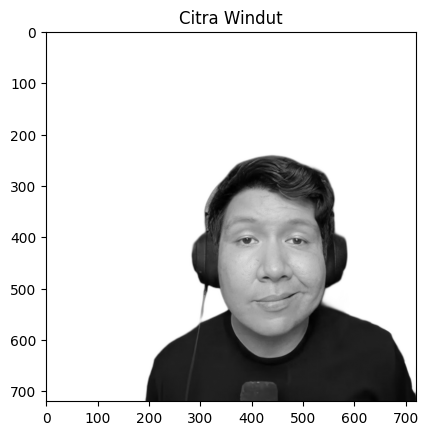

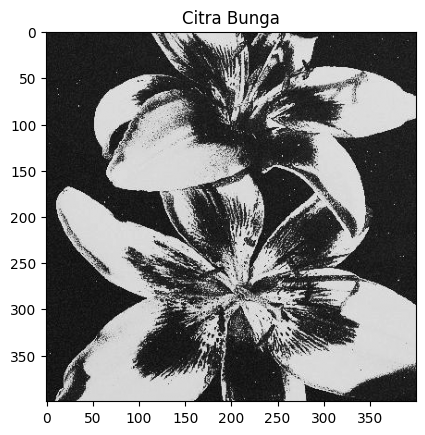

In [154]:
windut = cv2.imread('Assets/Windut.PNG', 0)
bunga = cv2.imread('Assets/Bunga.PNG', 0)

plt.title('A')
plt.imshow(windut, cmap='gray')
plt.title('Citra Windut')
plt.show()

plt.imshow(bunga, cmap='gray')
plt.title('Citra Bunga')
plt.show()

In [155]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)
    for y in range(citra_asal.shape[0]):
        for x in range(citra_asal.shape[1]):
            pixel = citra_asal[y, x]
            hist_asal[pixel] += 1
    for y in range(citra_target.shape[0]):
        for x in range(citra_target.shape[1]):
            pixel = citra_target[y, x]
            hist_target[pixel] += 1
    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)
    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]
    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]
    map_hist = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        min_selisih = abs(cdf_asal[i] - cdf_target[0])
        indeks = 0
        for j in range(1, 256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < min_selisih:
                min_selisih = selisih
                indeks = j
        map_hist[i] = indeks
    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)
    for y in range(height):
        for x in range(width):
            pixel = citra_asal[y, x]
            hasil[y, x] = map_hist[pixel]
    return hasil

Kode di atas digunakan untuk membuat fungsi spesifikasi_histogram() yang berfungsi melakukan histogram specification atau histogram matching antara citra asal dan citra target. Proses ini bertujuan agar distribusi intensitas pada citra asal menyesuaikan dengan distribusi intensitas citra target.
Pada awal fungsi dibuat dua array histogram menggunakan np.zeros(256, dtype=int) untuk menyimpan jumlah kemunculan setiap intensitas piksel dari 0–255 pada citra asal dan citra target. Setelah itu dilakukan perulangan menggunakan for untuk membaca setiap piksel pada kedua citra dan menghitung frekuensi kemunculan nilai intensitasnya.
Selanjutnya program membuat nilai CDF (Cumulative Distribution Function) untuk kedua histogram. Nilai CDF dihitung secara kumulatif, yaitu menjumlahkan seluruh frekuensi dari intensitas sebelumnya hingga intensitas saat ini. Setelah dihitung, nilai CDF dinormalisasi dengan membaginya menggunakan nilai maksimum agar berada pada rentang 0–1.
Program kemudian membuat array map_hist yang digunakan sebagai tabel pemetaan intensitas. Pada bagian ini dilakukan pencarian nilai intensitas pada citra target yang memiliki selisih CDF paling kecil terhadap citra asal. Nilai tersebut kemudian disimpan sebagai pasangan pemetaan histogram.
Setelah proses pemetaan selesai, program membuat citra hasil dengan ukuran yang sama seperti citra asal. Setiap piksel pada citra asal akan diganti menggunakan nilai baru berdasarkan tabel map_hist. Hasil akhirnya adalah citra yang karakteristik histogramnya menyerupai citra target.

Kode di bawah digunakan untuk menjalankan fungsi spesifikasi histogram yang telah dibuat sebelumnya. Fungsi spesifikasi_histogram(windut, bunga) digunakan untuk mengubah distribusi intensitas citra Windut agar menyerupai distribusi intensitas citra Bunga. Hasil proses tersebut disimpan ke dalam variabel hasil_spesifikasi. Selanjutnya program membuat figure dengan ukuran 12x5 menggunakan plt.figure(figsize=(12,5)) agar tampilan gambar lebih jelas. Fungsi plt.imshow() digunakan untuk menampilkan hasil spesifikasi histogram dalam bentuk grayscale dengan parameter cmap='gray'.

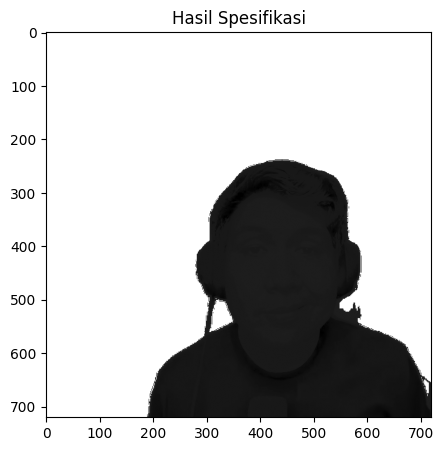

In [156]:
hasil_spesifikasi = spesifikasi_histogram(windut, bunga)
plt.figure(figsize=(12,5))
plt.imshow(hasil_spesifikasi, cmap='gray')
plt.title('Hasil Spesifikasi')
plt.show()

Kode di bawah ini digunakan untuk membuat dan menampilkan histogram dari hasil spesifikasi histogram yang sebelumnya telah diproses. Fungsi buat_hist(hasil_spesifikasi) digunakan untuk menghitung jumlah kemunculan setiap intensitas piksel pada citra hasil spesifikasi. Nilai histogram tersebut kemudian disimpan ke dalam variabel histogram_spesifikasi.
Setelah histogram berhasil dibuat, fungsi plot_histogram() digunakan untuk menampilkan grafik histogram. Parameter histogram_spesifikasi berisi data histogram yang akan ditampilkan, "Spesifikasi Windut dengan Bunga" digunakan sebagai judul grafik, sedangkan "red" digunakan untuk menentukan warna histogram menjadi merah.

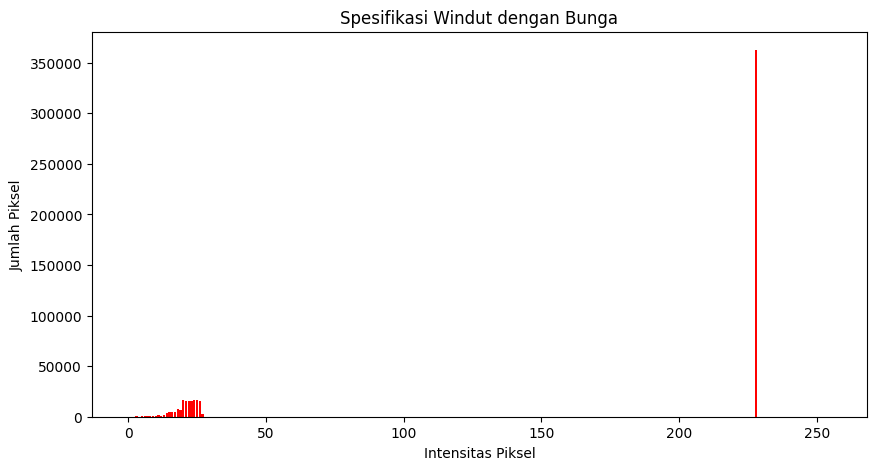

In [157]:
buat_hist(hasil_spesifikasi)
histogram_spesifikasi = buat_hist(hasil_spesifikasi)
plot_histogram(histogram_spesifikasi, "Spesifikasi Windut dengan Bunga", "red")

Kode di bawah ini digunakan untuk menyesuaikan ukuran citra hasil spesifikasi histogram dengan citra hasil ekualisasi sebelum kedua citra diproses lebih lanjut. Fungsi min() digunakan untuk mengambil ukuran tinggi dan lebar terkecil dari kedua citra agar dimensinya sama dan tidak menyebabkan error saat penggabungan atau masking dilakukan. Setelah ukuran ditentukan, program membuat array kosong bernama crop_spesifikasi menggunakan np.zeros() dengan ukuran sesuai nilai tinggi dan lebar. Array ini digunakan untuk menyimpan hasil cropping dari citra spesifikasi histogram. Kemudian dilakukan perulangan menggunakan for untuk menyalin setiap piksel dari hasil_spesifikasi ke dalam crop_spesifikasi. Proses ini menghasilkan citra spesifikasi yang ukurannya sudah disesuaikan dengan citra hasil ekualisasi.

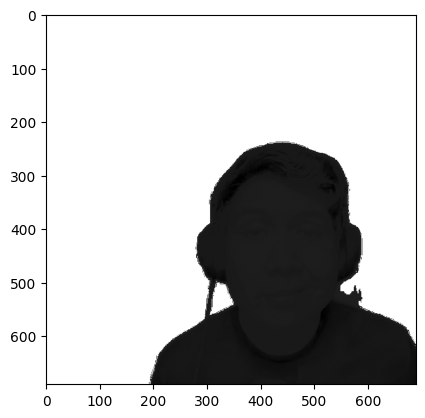

In [158]:
tinggi = min(hasil_spesifikasi.shape[0], hasil_ekualisasi.shape[0])
lebar = min(hasil_spesifikasi.shape[1], hasil_ekualisasi.shape[1])

crop_spesifikasi = np.zeros((tinggi, lebar), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        crop_spesifikasi[i,j] = hasil_spesifikasi[i,j]

plt.imshow(crop_spesifikasi, cmap='gray')
plt.show()

In [159]:
def masking(background, objek):
    hasil = background.copy()
    mask = objek < 50
    hasil[mask] = objek[mask]
    return hasil

Kode di atas digunakan untuk membuat fungsi masking() yang berfungsi menggabungkan objek ke dalam background menggunakan teknik masking. Fungsi ini menerima dua parameter, yaitu background sebagai citra latar belakang dan objek sebagai citra objek yang akan ditempelkan.
Di dalam fungsi, variabel hasil dibuat menggunakan background.copy() agar proses pengubahan tidak mempengaruhi citra asli. Selanjutnya dibuat variabel mask dengan kondisi objek < 50. Kondisi ini digunakan untuk mendeteksi piksel gelap pada citra objek, karena piksel dengan nilai intensitas kurang dari 50 dianggap sebagai bagian objek yang ingin dipertahankan. Baris hasil[mask] = objek[mask] digunakan untuk mengganti piksel pada background dengan piksel objek sesuai area yang memenuhi kondisi mask. Dengan cara ini, bagian tertentu dari objek akan ditempelkan ke background. Setelah proses selesai, fungsi mengembalikan hasil gabungan menggunakan return hasil.

Kode di bawah digunakan untuk menjalankan fungsi masking yang telah dibuat sebelumnya. Fungsi masking(hasil_ekualisasi, crop_spesifikasi) digunakan untuk menggabungkan citra hasil ekualisasi sebagai background dengan citra hasil spesifikasi histogram sebagai objek. Hasil penggabungan tersebut disimpan ke dalam variabel hasil_gabung.

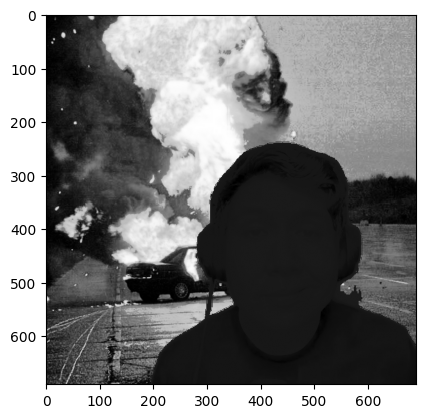

In [160]:
hasil_gabung = masking(hasil_ekualisasi, crop_spesifikasi)

plt.imshow(hasil_gabung, cmap='gray')
plt.show()

Kode di bawah ini digunakan untuk menyesuaikan ukuran citra Windut dengan citra hasil gabungan agar kedua citra memiliki dimensi yang sama sebelum dilakukan proses lanjutan. Fungsi min() digunakan untuk mengambil nilai tinggi dan lebar terkecil dari kedua citra, yaitu hasil_gabung dan windut. Dengan cara ini, program menghindari terjadinya error akibat perbedaan ukuran gambar saat proses pengolahan citra dilakukan. Selanjutnya program membuat array kosong bernama windut_crop menggunakan np.zeros() dengan ukuran sesuai nilai tinggi dan lebar. Array ini digunakan untuk menyimpan hasil cropping citra Windut.Kemudian dilakukan perulangan menggunakan for untuk menyalin setiap piksel dari citra windut ke dalam windut_crop. Proses ini menghasilkan citra Windut dengan ukuran yang sudah disesuaikan dengan citra hasil gabungan.

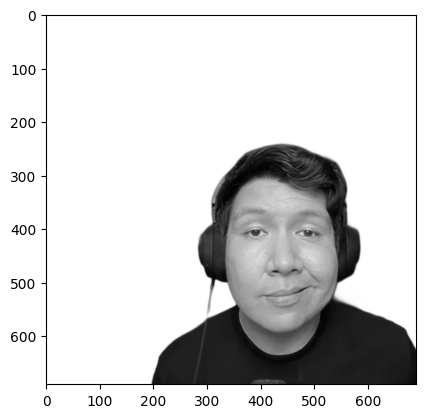

In [161]:
tinggi = min(hasil_gabung.shape[0], windut.shape[0])
lebar = min(hasil_gabung.shape[1], windut.shape[1])

windut_crop = np.zeros((tinggi, lebar), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        windut_crop[i,j] = windut[i,j]

plt.imshow(windut_crop, cmap='gray')
plt.show()

Kode di bawah ini digunakan untuk menempelkan citra Windut yang sudah di-crop ke dalam citra hasil gabungan menggunakan proses masking sederhana berdasarkan nilai intensitas piksel. Variabel hasil_foto dibuat menggunakan hasil_gabung.copy() agar perubahan yang dilakukan tidak mengubah citra asli hasil_gabung.
Selanjutnya program melakukan perulangan pada seluruh piksel gambar menggunakan for. Pada setiap iterasi, nilai piksel dari windut_crop diambil dan disimpan ke dalam variabel pixel. Kemudian dilakukan pengecekan dengan kondisi if pixel < 240. Kondisi ini digunakan untuk mendeteksi bagian objek Windut yang bukan berwarna putih atau terlalu terang. Piksel yang memiliki nilai kurang dari 240 dianggap sebagai bagian objek yang ingin dipertahankan. Jika kondisi terpenuhi, maka nilai piksel pada hasil_foto akan diganti dengan nilai piksel dari windut_crop. Dengan cara ini, objek Windut dapat ditempelkan ke citra hasil gabungan sementara background putihnya diabaikan.

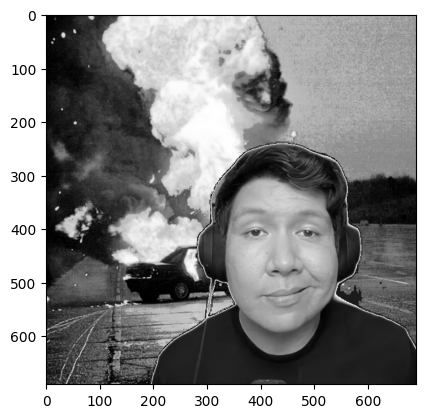

In [162]:
hasil_foto = hasil_gabung.copy()
for i in range(hasil_foto.shape[0]):
    for j in range(hasil_foto.shape[1]):
        pixel = windut_crop[i,j]
        if pixel < 240:
            hasil_foto[i,j] = pixel

plt.imshow(hasil_foto, cmap='gray')
plt.show()

Kode di bawah ini digunakan untuk membaca dan menampilkan citra Langit dalam bentuk asli dan grayscale. Pada baris langit = plt.imread('Assets/Langit.PNG', 0), program membaca gambar Langit dari folder Assets menggunakan fungsi plt.imread(). Hasil gambar kemudian ditampilkan menggunakan plt.imshow() dengan parameter cmap='gray' agar citra ditampilkan dalam skala abu-abu. Fungsi plt.title() digunakan untuk memberi judul “Citra Langit”, sedangkan plt.show() digunakan untuk menampilkan gambar ke layar.
Selanjutnya program membaca kembali gambar Langit menggunakan fungsi cv2.imread('Assets/Langit.PNG', 0). Parameter 0 menunjukkan bahwa gambar dibaca langsung dalam mode grayscale. Hasil pembacaan tersebut disimpan ke dalam variabel langit_grey.
Citra grayscale kemudian ditampilkan menggunakan plt.imshow() dengan parameter cmap='gray', lalu diberi judul “Citra Langit (Grayscale)” menggunakan plt.title(). Fungsi plt.show() digunakan untuk menampilkan hasil akhir ke layar.

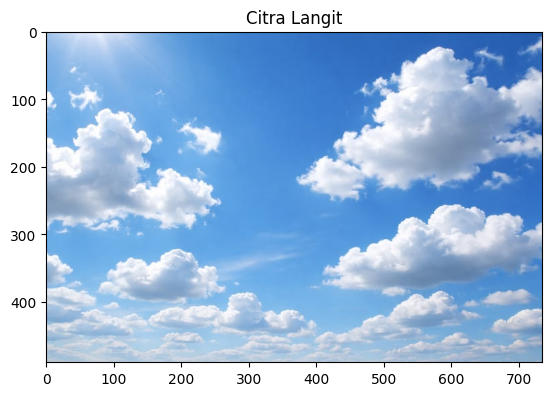

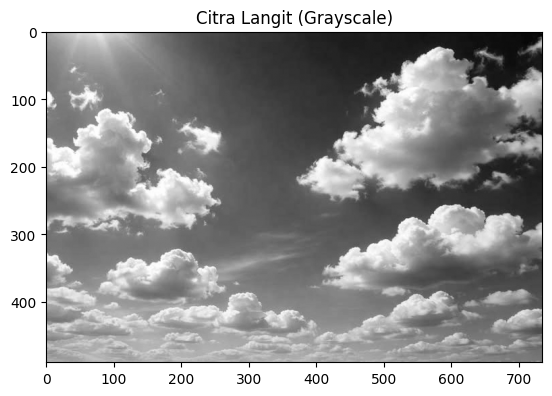

In [163]:
langit = plt.imread('Assets/Langit.PNG', 0)
plt.imshow(langit, cmap='gray')
plt.title('Citra Langit')
plt.show()

langit_grey = cv2.imread('Assets/Langit.PNG', 0)
plt.imshow(langit_grey, cmap='gray')
plt.title('Citra Langit (Grayscale)')
plt.show()

Kode di bawah ini digunakan untuk melakukan proses spesifikasi histogram antara citra hasil_foto dengan citra langit_grey. Fungsi spesifikasi_histogram(hasil_foto, langit_grey) digunakan untuk menyesuaikan distribusi intensitas piksel pada citra hasil_foto agar menyerupai distribusi intensitas pada citra Langit grayscale. Hasil proses tersebut disimpan ke dalam variabel spesifikasi_langit. Selanjutnya program membuat figure dengan ukuran 12x5 menggunakan plt.figure(figsize=(12,5)) agar tampilan gambar lebih jelas dan proporsional. 

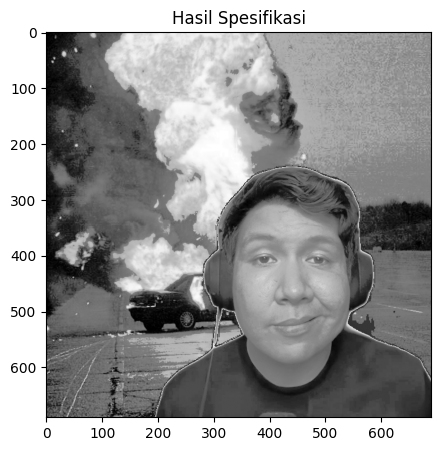

In [164]:
spesifikasi_langit = spesifikasi_histogram(hasil_foto, langit_grey)
plt.figure(figsize=(12,5))
plt.imshow(spesifikasi_langit, cmap='gray')
plt.title('Hasil Spesifikasi')
plt.show()

Kode di bawah ini digunakan untuk membuat dan menampilkan histogram dari hasil spesifikasi histogram antara citra Windut dan citra Langit. Fungsi buat_hist(spesifikasi_langit) digunakan untuk menghitung jumlah kemunculan setiap intensitas piksel pada citra hasil spesifikasi. Histogram yang dihasilkan kemudian disimpan ke dalam variabel histogram_spesifikasi. Setelah histogram berhasil dibuat, fungsi plot_histogram() digunakan untuk menampilkan grafik histogram. Parameter histogram_spesifikasi berisi data histogram yang akan divisualisasikan, "Spesifikasi Windut dengan Langit" digunakan sebagai judul grafik, sedangkan "red" digunakan untuk menentukan warna histogram menjadi merah.

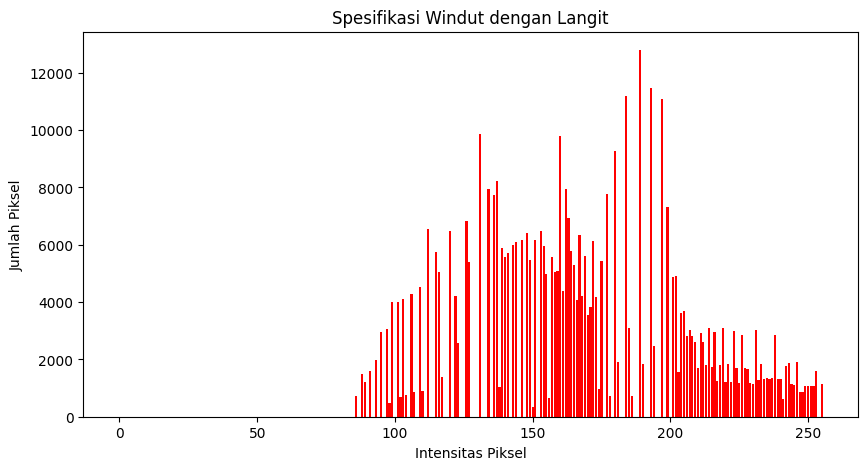

In [165]:
buat_hist(spesifikasi_langit)
histogram_spesifikasi = buat_hist(spesifikasi_langit)
plot_histogram(histogram_spesifikasi,  "Spesifikasi Windut dengan Langit", "red")

Kode di bawah ini digunakan untuk membaca dan menampilkan citra background serta citra objek yang akan digunakan pada proses penggabungan gambar berwarna. Pada baris meledak_blue = cv2.cvtColor(hasil_akhir, cv2.COLOR_BGR2RGB), program mengubah format warna citra hasil_akhir dari BGR menjadi RGB menggunakan fungsi cv2.cvtColor(). Perubahan ini dilakukan karena OpenCV membaca gambar dalam format BGR, sedangkan Matplotlib menampilkan gambar dalam format RGB. Hasil konversi kemudian disimpan ke dalam variabel meledak_blue. Selanjutnya fungsi plt.imshow(meledak_blue) digunakan untuk menampilkan citra background hasil penggabungan sebelumnya, lalu plt.show() digunakan untuk menampilkan gambar ke layar. Pada bagian berikutnya, program membaca gambar Windut berwarna menggunakan cv2.imread('Assets/Windut.PNG'). Karena tidak menggunakan parameter 0, gambar dibaca dalam mode warna asli RGB/BGR. Hasil pembacaan disimpan ke dalam variabel windut.

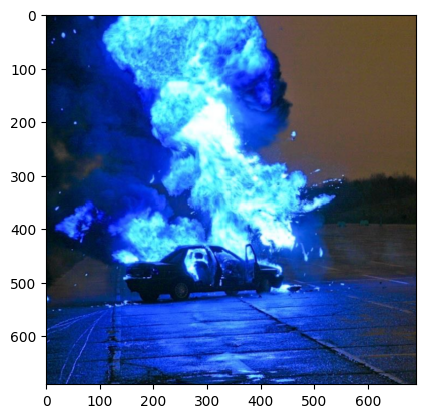

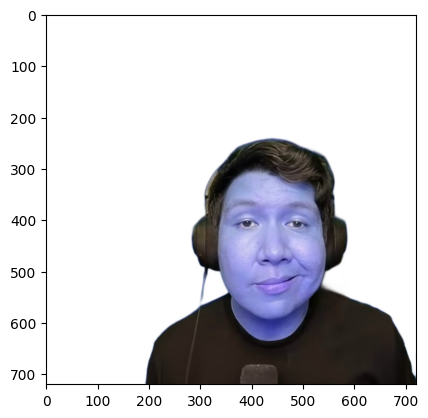

In [166]:
meledak_blue = cv2.cvtColor(hasil_akhir, cv2.COLOR_BGR2RGB)
plt.imshow(meledak_blue)
plt.show()

windut = cv2.imread('Assets/Windut.PNG')
plt.imshow(windut)
plt.show()

Kode di bawah ini digunakan untuk menyamakan ukuran citra background meledak_blue dengan citra objek windut sebelum dilakukan proses penggabungan gambar berwarna. Fungsi min() digunakan untuk mengambil ukuran tinggi dan lebar terkecil dari kedua citra agar dimensinya sama dan tidak menyebabkan error saat pengolahan citra dilakukan. Setelah ukuran ditentukan, program membuat dua array kosong bernama bg_crop dan wd_crop menggunakan np.zeros(). Kedua array tersebut memiliki ukuran (tinggi, lebar, 3) karena gambar yang digunakan merupakan citra berwarna RGB yang memiliki tiga channel warna, yaitu merah, hijau, dan biru. Parameter dtype=np.uint8 digunakan agar tipe data piksel sesuai dengan format citra digital. Kemudian dilakukan perulangan menggunakan for untuk menyalin setiap piksel dari citra background meledak_blue ke dalam bg_crop, dan setiap piksel dari citra windut ke dalam wd_crop. Proses ini menghasilkan dua citra baru yang memiliki ukuran sama sehingga siap digunakan untuk proses masking atau penggabungan citra RGB.

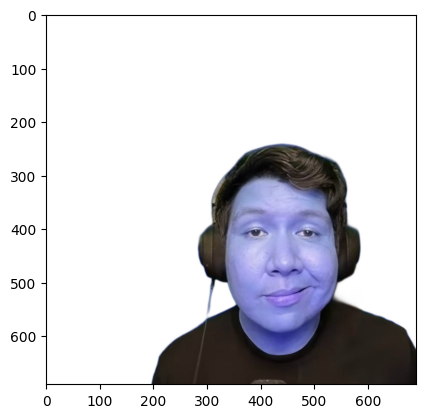

In [167]:
tinggi = min(meledak_blue.shape[0], windut.shape[0])
lebar = min(meledak_blue.shape[1], windut.shape[1])

bg_crop = np.zeros((tinggi, lebar, 3), dtype=np.uint8)
wd_crop = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):

        bg_crop[i,j] = meledak_blue[i,j]
        wd_crop[i,j] = windut[i,j]
plt.imshow(wd_crop)
plt.show()

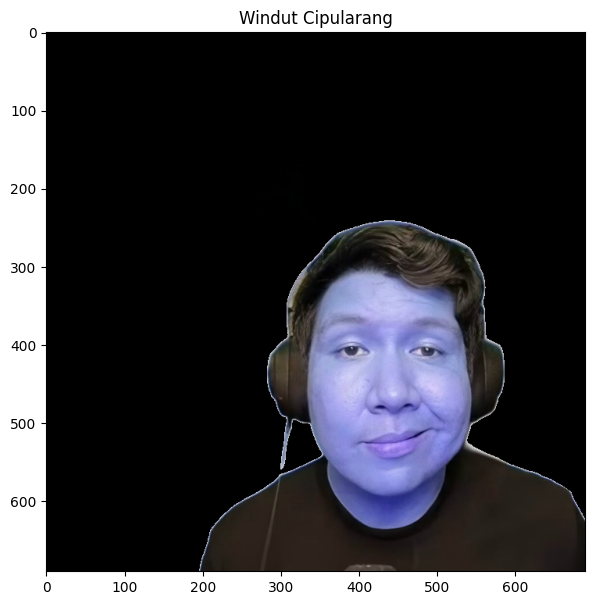

In [170]:
mask = np.zeros((tinggi, lebar), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):

        r = windut[i, j][0]
        g = windut[i, j][1]
        b = windut[i, j][2]

        if r > 220 and g > 220 and b > 220:
            mask[i, j] = 0
        else:
            mask[i, j] = 1


final = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):

        if mask[i, j] == 1:
            final[i, j] = windut[i, j]

        else:
            final[i, j] = meledak_blue[i, j]


plt.figure(figsize=(7,7))
plt.title("Windut Cipularang")
plt.imshow(final)
plt.show()